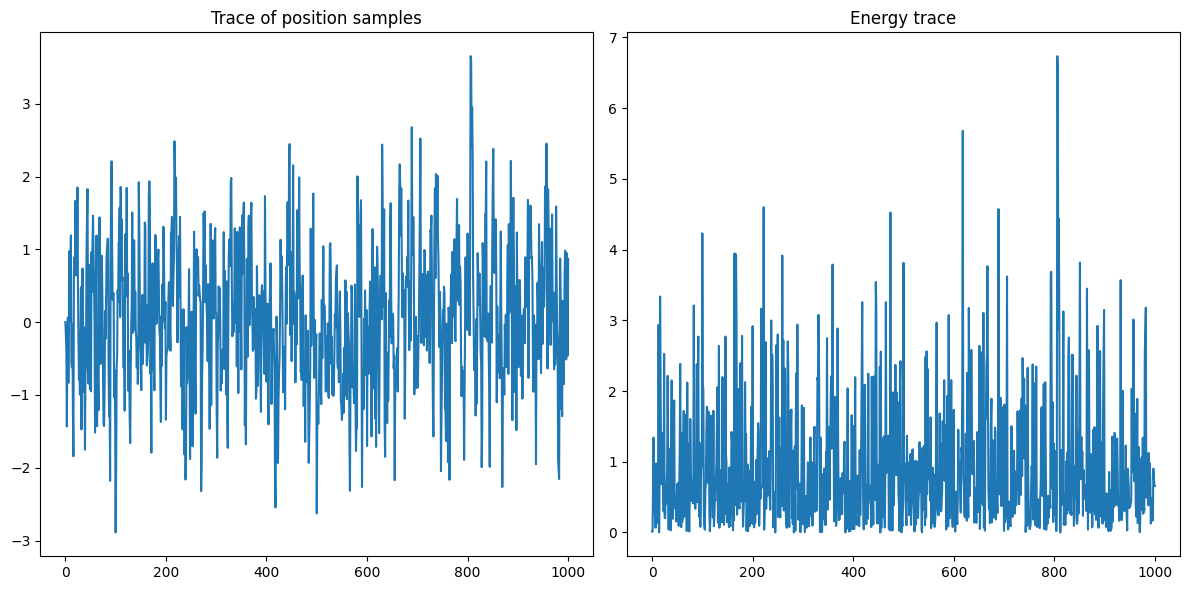

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the potential energy U(q) for a standard Gaussian distribution
def U(q):
    return 0.5 * q ** 2

# Define the gradient of the potential energy (i.e., the derivative of the log prob)
def grad_U(q):
    return q

# Define the kinetic energy K(p) assuming a standard Gaussian for the momentum
def K(p):
    return 0.5 * p ** 2

# Hamiltonian (sum of potential and kinetic energies)
def H(q, p):
    return U(q) + K(p)

# The leapfrog method for integrating the equations of motion
def leapfrog(q, p, step_size, n_steps):
    q_new = q
    p_new = p - 0.5 * step_size * grad_U(q_new)  # half step for momentum

    for i in range(n_steps):
        q_new += step_size * p_new  # full step for position
        if i != n_steps - 1:
            p_new -= step_size * grad_U(q_new)  # full step for momentum

    p_new -= 0.5 * step_size * grad_U(q_new)  # half step for momentum

    return q_new, p_new

# The HMC transition
def hmc_transition(q_current, step_size, n_steps):
    p_current = np.random.normal()  # sample momentum
    q_new, p_new = leapfrog(q_current, p_current, step_size, n_steps)
    
    # Metropolis acceptance step
    current_H = H(q_current, p_current)
    new_H = H(q_new, p_new)
    if np.random.rand() < np.exp(current_H - new_H):
        return q_new  # accept
    else:
        return q_current  # reject

# Run the HMC sampler
def run_hmc(steps, step_size, n_leapfrog):
    q = 0.0
    samples = [q]
    energies = [H(q, np.random.normal())]
    
    for step in range(steps):
        q_new = hmc_transition(q, step_size, n_leapfrog)
        samples.append(q_new)
        energies.append(H(q_new, np.random.normal()))
        q = q_new
    
    return samples, energies

# Parameters
n_samples = 1000
step_size = 0.1
n_leapfrog_steps = 10

samples, energies = run_hmc(n_samples, step_size, n_leapfrog_steps)

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(samples)
plt.title('Trace of position samples')

plt.subplot(1, 2, 2)
plt.plot(energies)
plt.title('Energy trace')

plt.tight_layout()
plt.show()


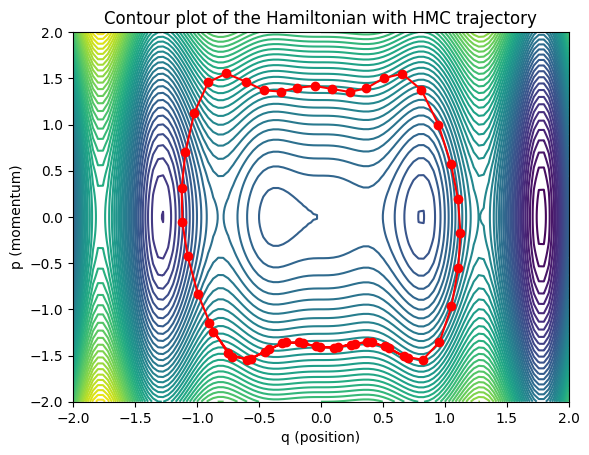

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Define a more complex potential energy function U(q) for visualization
def U(q):
    return 0.5 * (q ** 2) * np.sin(2 * np.pi * q)

# Define the gradient of the potential energy function
def grad_U(q):
    return q * np.pi * np.cos(2 * np.pi * q) + q

# Define the kinetic energy function K(p) with standard Gaussian momentum
def K(p):
    return 0.5 * p ** 2

# Hamiltonian function
def H(q, p):
    return U(q) + K(p)

# Leapfrog integrator
def leapfrog(q, p, step_size, n_steps):
    q_new = q
    p_new = p - 0.5 * step_size * grad_U(q_new)

    trajectory = [(q_new, p_new)]

    for i in range(n_steps):
        q_new += step_size * p_new
        p_new -= step_size * grad_U(q_new)
        trajectory.append((q_new, p_new))

    p_new -= 0.5 * step_size * grad_U(q_new)

    return q_new, p_new, trajectory

# Running the HMC transition
def hmc_transition(q_current, step_size, n_steps):
    p_current = np.random.normal()
    q_new, p_new, trajectory = leapfrog(q_current, p_current, step_size, n_steps)

    current_H = H(q_current, p_current)
    new_H = H(q_new, p_new)
    if np.random.rand() < np.exp(current_H - new_H):
        return q_new, trajectory  # accept
    else:
        return q_current, trajectory  # reject

# Function to plot the energy contours and trajectory
def plot_energy_contours_trajectory(step_size, n_steps):
    q_vals = np.linspace(-2, 2, 100)
    p_vals = np.linspace(-2, 2, 100)
    Q, P = np.meshgrid(q_vals, p_vals)
    H_vals = H(Q, P)

    q_current = np.random.uniform(-2, 2)
    _, trajectory = hmc_transition(q_current, step_size, n_steps)

    trajectory = np.array(trajectory)

    plt.contour(Q, P, H_vals, levels=50)
    plt.plot(trajectory[:, 0], trajectory[:, 1], marker='o', color='red')
    plt.title('Contour plot of the Hamiltonian with HMC trajectory')
    plt.xlabel('q (position)')
    plt.ylabel('p (momentum)')
    plt.show()

# Parameters for the HMC
step_size = 0.1
n_leapfrog_steps = 50

# Generate and plot the contours and trajectory
plot_energy_contours_trajectory(step_size, n_leapfrog_steps)


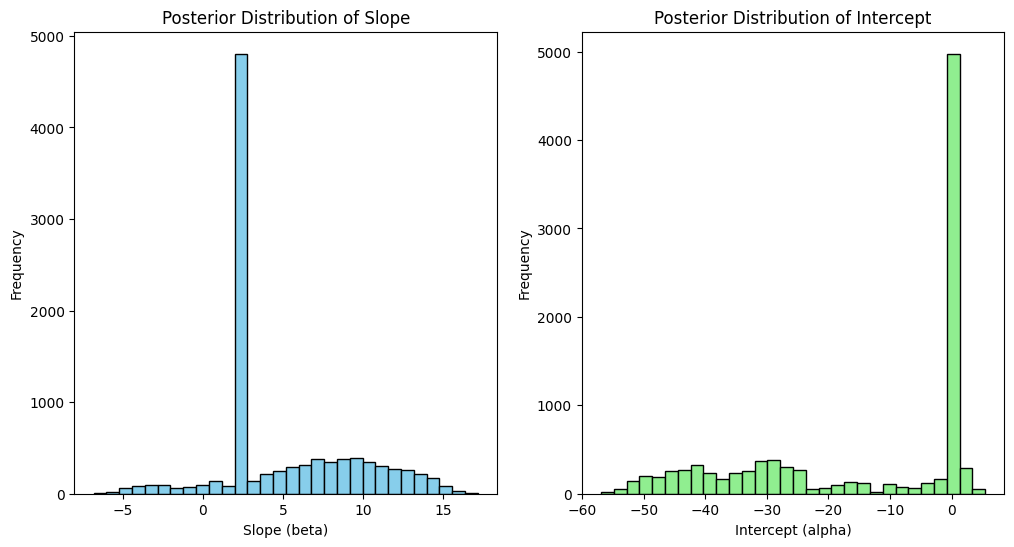

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Simulate some data
np.random.seed(42)
X = np.linspace(0, 10, 100)
true_slope = 2.5
true_intercept = 1.0
Y = true_slope * X + true_intercept + np.random.normal(scale=1.0, size=X.shape)

# Step 2: Define the log-likelihood function
def log_likelihood(beta, alpha, sigma, X, Y):
    Y_pred = alpha + X * beta
    return -0.5 * np.sum(np.log(2 * np.pi * sigma ** 2) + (Y - Y_pred) ** 2 / sigma ** 2)

# Step 3: Define the log-prior function
def log_prior(beta, alpha, sigma):
    # Flat priors for beta and alpha, log-normal for sigma
    if sigma <= 0:
        return -np.inf  # log(0)
    return -np.log(sigma)

# Step 4: Compute the gradient of the log-posterior
def grad_log_posterior(beta, alpha, sigma, X, Y):
    Y_pred = alpha + X * beta
    dL_dbeta = np.sum((Y - Y_pred) * X) / sigma ** 2
    dL_dalpha = np.sum(Y - Y_pred) / sigma ** 2
    dL_dsigma = -len(Y) / sigma + np.sum((Y - Y_pred) ** 2) / sigma ** 3
    return np.array([dL_dbeta, dL_dalpha, dL_dsigma])

# Step 5: Implement the leapfrog integration method
def leapfrog(theta, r, grad, eps, X, Y, sigma):
    r_half_step = r + 0.5 * eps * grad(theta[0], theta[1], sigma, X, Y)
    theta_full_step = theta + eps * r_half_step
    r_full_step = r_half_step + 0.5 * eps * grad(theta_full_step[0], theta_full_step[1], sigma, X, Y)
    return theta_full_step, r_full_step

# Step 6: HMC sampling
def hmc_sampling(init, n_samples, eps, leapfrog_steps, X, Y):
    samples = [init]
    current_theta = np.array(init)
    
    for _ in range(n_samples):
        r = np.random.normal(size=current_theta.shape)
        theta_proposed, r_proposed = current_theta, r
        
        for _ in range(leapfrog_steps):
            theta_proposed, r_proposed = leapfrog(theta_proposed, r_proposed, grad_log_posterior, eps, X, Y, current_theta[2])
        
        # Metropolis-Hastings acceptance
        current_log_post = log_likelihood(*current_theta, X, Y) + log_prior(*current_theta)
        proposed_log_post = log_likelihood(*theta_proposed, X, Y) + log_prior(*theta_proposed)
        if np.log(np.random.rand()) < proposed_log_post - current_log_post:
            current_theta = theta_proposed
        
        samples.append(current_theta)
    
    return np.array(samples)

# Initial parameters
init_params = [1, 1, 1]  # Initial guesses for beta, alpha, sigma

# Run HMC
samples = hmc_sampling(init_params, 10000, 0.01, 50, X, Y)

# Plot the sampled regression coefficients
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(samples[:, 0], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Slope (beta)')
plt.ylabel('Frequency')
plt.title('Posterior Distribution of Slope')

plt.subplot(1, 2, 2)
plt.hist(samples[:, 1], bins=30, color='lightgreen', edgecolor='black')
plt.xlabel('Intercept (alpha)')
plt.ylabel('Frequency')
plt.title('Posterior Distribution of Intercept')
plt.show()


In [3]:
import numpy as np

# Assume some linear regression parameters
beta = 2.0  # Slope
alpha = 1.0  # Intercept
sigma = 1.0  # Standard deviation of the residuals/error

# Assume some data
X = np.linspace(0, 10, 100)  # Independent variable
Y = alpha + beta * X + np.random.normal(0, sigma, size=X.shape[0])  # Dependent variable

# Define the potential energy (U) as the negative log-likelihood
def potential_energy(beta, alpha, sigma, X, Y):
    n = len(Y)
    residuals = Y - (alpha + beta * X)
    # Negative log-likelihood for Gaussian errors
    U = 0.5 * n * np.log(2 * np.pi * sigma ** 2) + np.sum(residuals ** 2) / (2 * sigma ** 2)
    return U

# Define the kinetic energy (K) with momentum (p) having a mass matrix (M)
def kinetic_energy(p, M):
    # Kinetic energy: K = p^T * M^-1 * p / 2
    # For simplicity, M is often chosen as the identity matrix
    M_inv = np.linalg.inv(M)
    K = 0.5 * np.dot(p.T, np.dot(M_inv, p))
    return K

# Example usage:

# Compute the potential energy for the current position in parameter space
U = potential_energy(beta, alpha, sigma, X, Y)

# Assume a momentum vector (p) and a mass matrix (M)
p = np.random.randn(2)  # Random momentum for beta and alpha
M = np.eye(2)  # Identity mass matrix for simplicity

# Compute the kinetic energy for the current momentum
K = kinetic_energy(p, M)

print(f"Potential Energy (U): {U}")
print(f"Kinetic Energy (K): {K}")


Potential Energy (U): 137.36689834212456
Kinetic Energy (K): 0.45286473551733025


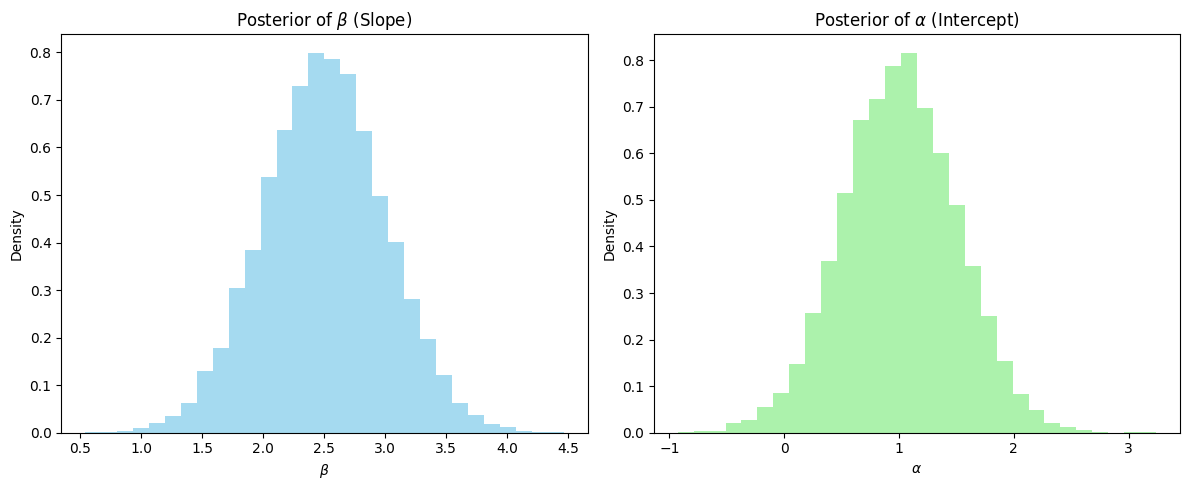

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'samples' is a NumPy array with shape (n_samples, n_parameters)
# where the first column is beta and the second is alpha

# Generate synthetic data for demonstration purposes
# Normally, 'samples' would be the output of your HMC sampler
np.random.seed(42)
true_slope = 2.5
true_intercept = 1.0
n_samples = 10000
samples = np.empty((n_samples, 2))
samples[:, 0] = np.random.normal(true_slope, 0.5, n_samples)  # Slope samples
samples[:, 1] = np.random.normal(true_intercept, 0.5, n_samples)  # Intercept samples

# Plotting the posterior distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Posterior for beta (slope)
axes[0].hist(samples[:, 0], bins=30, density=True, color='skyblue', alpha=0.75)
axes[0].set_title('Posterior of $\\beta$ (Slope)')
axes[0].set_xlabel('$\\beta$')
axes[0].set_ylabel('Density')

# Posterior for alpha (intercept)
axes[1].hist(samples[:, 1], bins=30, density=True, color='lightgreen', alpha=0.75)
axes[1].set_title('Posterior of $\\alpha$ (Intercept)')
axes[1].set_xlabel('$\\alpha$')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()
